# Paper figures
Regenerates every results figure for the paper and writes a PDF into `figures/`.
Run top-to-bottom with the `nn4opt` kernel. Edit the `configs` lists to add/remove
experiments. See `RESULTS_LAYOUT.md` for where each input lives.

In [14]:
import sys, pathlib, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = pathlib.Path.cwd().parent  # repo root (notebook lives in notebooks/)
sys.path.insert(0, str(ROOT))
RESULTS, FIGS, DATA = ROOT/'results', ROOT/'figures', ROOT/'data'

# Consistent per-experiment colors (matches the paper).
EXP_COLOR = {'MIMO':'tab:blue','IK':'purple','AC-OPF':'tab:orange',
             'knapsack':'black','QCQP':'tab:green'}
plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.grid':True,'grid.alpha':0.3})

## 1. Training history
Train/val MSE (standardized target) for a representative fold, log scale.

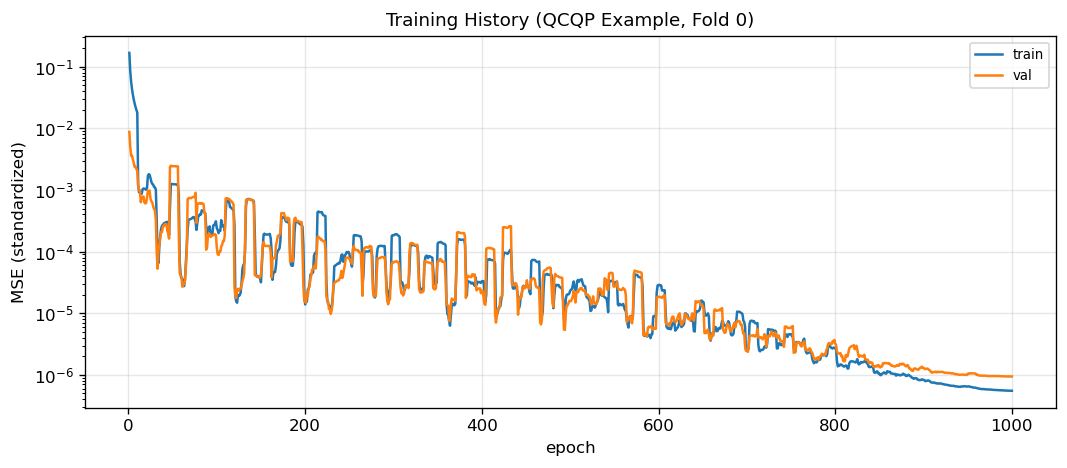

In [37]:
h = pd.read_csv(FIGS/'training_history_qcqp_fold0.csv')
plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(9,4))
w = max(1, len(h)//100)
ax.plot(h.epoch, h.train_mse.rolling(w,min_periods=1).mean(), label='train')
ax.plot(h.epoch, h.val_mse.rolling(w,min_periods=1).mean(), label='val')
ax.set_yscale('log')
ax.set_xlabel('epoch')
ax.set_ylabel('MSE (standardized)')
ax.set_title('Training History (QCQP Example, Fold 0)', fontsize=11)
ax.legend(fontsize=10)
fig.tight_layout(); fig.savefig(FIGS/'fig_training_history.pdf'); plt.show()

## 2. Normalized prediction-error box-and-whisker
Absolute NN error |g − v_r| normalized by std(v_r) over the test set, so every
experiment sits on a comparable scale. Pools all four folds.

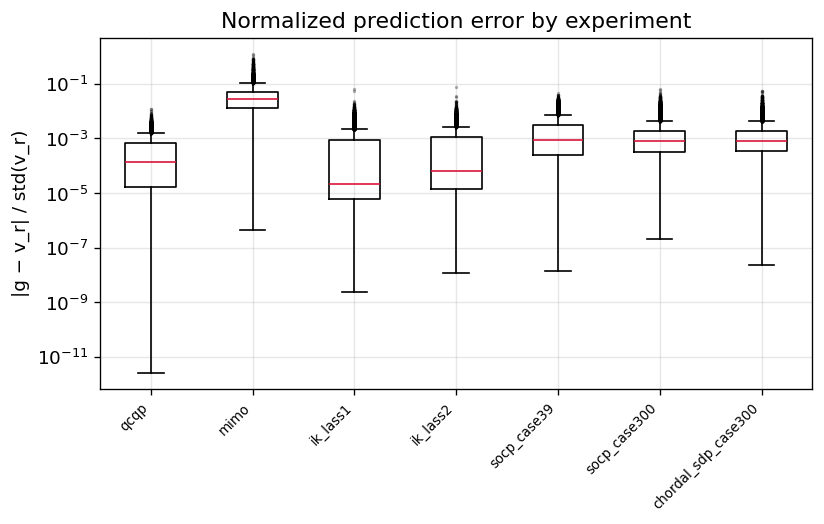

In [3]:
def small_pred(key):
    return pd.read_csv(RESULTS/key/'fold_test_predictions.csv')
def acopf_pred(cfg):
    return pd.read_csv(RESULTS/'acopf-cert'/cfg/'fold_test_predictions.csv')

# choose which configs to show (edit freely)
configs = [('qcqp',small_pred('qcqp')),('mimo',small_pred('mimo')),
           ('ik_lass1',small_pred('ik_lass1')),('ik_lass2',small_pred('ik_lass2'))]
for cfg in ['acopf_socp_case39','acopf_socp_case300','acopf_chordal_sdp_case300']:
    p = RESULTS/'acopf-cert'/cfg/'fold_test_predictions.csv'
    if p.exists(): configs.append((cfg.replace('acopf_',''), pd.read_csv(p)))

data, labels = [], []
for name, d in configs:
    err = np.abs(d['g']-d['v']).values
    s = d['v'].std() or 1.0
    data.append(err/s); labels.append(name)
fig, ax = plt.subplots(figsize=(max(7,0.8*len(labels)),4.5))
ax.boxplot(data, tick_labels=labels, showfliers=True,
           flierprops=dict(marker='.',markersize=2,alpha=0.3),
           medianprops=dict(color='crimson'))
ax.set_yscale('log'); ax.set_ylabel('|g − v_r| / std(v_r)')
ax.set_title('Normalized prediction error by experiment')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
fig.tight_layout(); fig.savefig(FIGS/'fig_error_boxplot.pdf'); plt.show()

## 3. ROC curves
One curve per classifier from `results/roc_curves/<config>.npz`, colored by
experiment. AUC in the legend.

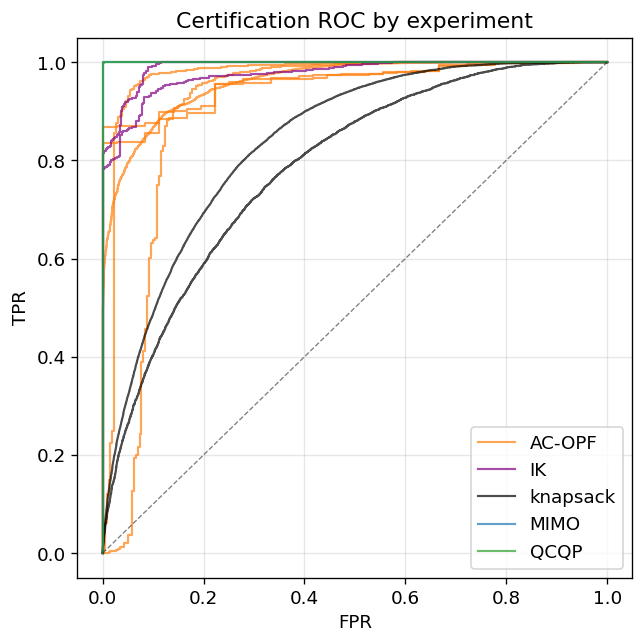

,config,auc,n_pos,n_neg
0,qcqp,0.999974,10036,9964
1,mimo,1.000000,19984,16
2,ik_lass1,0.975088,19100,872
3,ik_lass2,0.989888,19100,872
4,acopf_socp_case9,NaN,20000,0
5,acopf_socp_case14,NaN,20000,0
6,acopf_socp_case39,0.955866,18568,36
7,acopf_socp_case89pegase,NaN,19092,0
8,acopf_socp_case118,NaN,20000,0
9,acopf_socp_case300,0.899299,15508,260


In [4]:
def exp_of(cfg):
    if cfg.startswith('acopf'): return 'AC-OPF'
    if cfg.startswith('ik'): return 'IK'
    if cfg=='mimo': return 'MIMO'
    if cfg=='qcqp': return 'QCQP'
    if 'knapsack' in cfg: return 'knapsack'
    return 'other'

fig, ax = plt.subplots(figsize=(5.5,5.5))
seen=set()
for f in sorted((RESULTS/'roc_curves').glob('*.npz')):
    z = np.load(f, allow_pickle=True); cfg=f.stem; e=exp_of(cfg)
    lbl = e if e not in seen else None; seen.add(e)
    ax.plot(z['fpr'], z['tpr'], color=EXP_COLOR.get(e,'gray'), alpha=0.7, lw=1.3, label=lbl)
ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Certification ROC by experiment')
ax.legend(); fig.tight_layout(); fig.savefig(FIGS/'fig_roc_curves.pdf'); plt.show()

# AUC table for reference
pd.read_csv(RESULTS/'roc_auc_summary.csv')[['config','auc','n_pos','n_neg']]

## 4. α–δ tradeoff at fixed certification level τ (QCQP)

The certificate declares δ-optimality at risk α when
$f(\hat x;\theta) \le \hat v(\theta) - q_\alpha + \delta$, where
$q_\alpha$ is the one-sided split-conformal offset from the calibration
residuals $e = g - v$: $q_\alpha = \mathrm{conformal\_offset}(e,\,1-\alpha)$
(the $\lceil (n{+}1)(1-\alpha)\rceil$-th smallest residual).

Define the certification level $\tau = \delta - q_\alpha$. For a **fixed** τ,
a whole family of $(\alpha,\delta)$ pairs achieves it:
$\delta(\alpha;\tau) = \tau + q_\alpha$. Each curve below is one τ; since they
differ only by the additive constant τ, they are vertical translations of the
single $q_\alpha(\alpha)$ profile — at a fixed certified level you trade risk
(α) against optimality gap (δ), and raising τ shifts the whole curve up.

Tweak `TAUS`, the α-range, colors, and opacities in the cell below.

In [ ]:
from nn.metrics import conformal_offset

# --- knobs -----------------------------------------------------------------
CONFIG = 'ik_lass2'                  # results/<CONFIG>/val_residuals.csv
CONFIG_LABEL = 'IK, Lasserre-2'
# tau values chosen near this experiment's residual scale so the alpha-elbow
# is visible rather than dwarfed by a large tau offset.
TAUS = [0.0005, 0.001, 0.002, 0.005, 0.01]
N_ALPHA = 400
ALPHA_MIN, ALPHA_MAX = 1e-3, 0.2     # plotted risk range
BASE_COLOR = 'steelblue'
LINEWIDTH = 3.0
OPACITY_HI, OPACITY_LO = 1.0, 0.35   # opacity decreases as tau increases

# Pool all per-fold validation residuals into one calibration set.
resid = pd.read_csv(RESULTS/CONFIG/'val_residuals.csv')['residual'].to_numpy(float)
resid = resid[np.isfinite(resid)]

# q_alpha via the exact order-statistic offset at level = 1 - alpha.
alphas = np.linspace(ALPHA_MIN, ALPHA_MAX, N_ALPHA)
q_alpha = np.array([conformal_offset(resid, 1.0 - a) for a in alphas])

fig, ax = plt.subplots(figsize=(7.0, 5.0))
opacities = np.linspace(OPACITY_HI, OPACITY_LO, len(TAUS))
for tau, opacity in zip(TAUS, opacities):
    ax.plot(alphas, tau + q_alpha, color=BASE_COLOR, linewidth=LINEWIDTH,
            alpha=opacity, label=rf'$\tau = {tau:g}$', solid_capstyle='round')
ax.set_xlabel(r'risk level $\alpha$'); ax.set_ylabel(r'optimality gap $\delta$')
ax.set_title(rf'$\alpha$–$\delta$ tradeoff at fixed certification level $\tau$ ({CONFIG_LABEL})')
ax.set_xlim(ALPHA_MIN, ALPHA_MAX)
ax.legend(title='certification level', frameon=False)
fig.tight_layout(); fig.savefig(FIGS/'fig_alpha_delta_tradeoff.pdf'); plt.show()

## 5. Certification operating characteristic (IK, Lasserre-2)

At a **fixed** τ the certificate rule collapses to
$f(\hat x;\theta) - g(\theta) \le \tau$, so τ alone determines which instances
are certified — the (α, δ) split in section 4 is just a reparametrization of
that single degree of freedom, and nothing observable changes along it.

The tradeoff with real, data-driven content comes from letting the **rule**
move: fix the risk level α = 1% (per-fold $q_{99}$) and sweep the claimed
optimality gap δ (as a % of std(v)). On the held-out test set this traces out
- **power** = fraction of truly δ-optimal test points we certify (rises from 0
  to 1 as δ crosses the residual scale), and
- **empirical FPR** = fraction of NOT-δ-optimal points we wrongly certify,
  which the split-conformal construction keeps at/below α the whole time.

That's the interesting curve: power climbing while the risk guarantee visibly
holds. The dashed line marks the paper's operating point (δ = 3% of std(v)).

In [ ]:
# --- knobs -------------------------------------------------------------
CONFIG = 'ik_lass2'
CONFIG_LABEL = 'IK, Lasserre-2'
ALPHA = 0.01                     # fixed risk level -> conformal level 0.99
LEVEL = 1.0 - ALPHA
DELTA_FRAC_MAX = 0.10            # sweep delta from 0 to this fraction of std(v)
N_DELTA = 300
OPERATING_DELTA_FRAC = 0.03      # paper's operating point, marked on the plot
POWER_COLOR = 'steelblue'
FPR_COLOR = 'crimson'
LINEWIDTH = 3.0

# Load per-fold test predictions (g, v, f) and the per-fold q_99 offset.
preds = pd.read_csv(RESULTS/CONFIG/'fold_test_predictions.csv')
off = pd.read_csv(RESULTS/CONFIG/'conformal_offsets.csv')
q_by_fold = off[np.isclose(off['level'], LEVEL)].set_index('fold')['offset'].to_dict()

# Sweep delta (absolute certificate: certify iff f <= g - q_99 + delta;
# truth iff f - v <= delta), pooling TP/FP/TN/FN across folds at each delta --
# matches scripts/compute_final_tables.py's convention exactly.
std_v = np.nanstd(preds['v'].to_numpy(float))
delta_fracs = np.linspace(0.0, DELTA_FRAC_MAX, N_DELTA)
power, fpr = [], []
for frac in delta_fracs:
    delta = frac * std_v
    tp = fp = tn = fn = 0
    for fold, sub in preds.groupby('fold'):
        g = sub['g'].to_numpy(float); v = sub['v'].to_numpy(float); f = sub['f'].to_numpy(float)
        ok = np.isfinite(g) & np.isfinite(v) & np.isfinite(f)
        g, v, f = g[ok], v[ok], f[ok]
        cert = f <= g - q_by_fold[fold] + delta
        truth = (f - v) <= delta
        tp += int(np.sum(cert & truth)); fp += int(np.sum(cert & ~truth))
        tn += int(np.sum(~cert & ~truth)); fn += int(np.sum(~cert & truth))
    power.append(tp/(tp+fn) if (tp+fn) else np.nan)
    fpr.append(fp/(fp+tn) if (fp+tn) else np.nan)
power, fpr = np.array(power), np.array(fpr)
x = delta_fracs * 100.0  # percent of std(v)

fig, ax = plt.subplots(figsize=(7.0, 5.0))
ax.plot(x, power, color=POWER_COLOR, lw=LINEWIDTH, label='power (certified fraction)')
ax.plot(x, fpr, color=FPR_COLOR, lw=LINEWIDTH, label='empirical FPR')
ax.axhline(ALPHA, color=FPR_COLOR, ls=':', lw=1.5, label=rf'target risk $\alpha={ALPHA:g}$')
ax.axvline(OPERATING_DELTA_FRAC*100.0, color='0.4', ls='--', lw=1.2)
ax.text(OPERATING_DELTA_FRAC*100.0, 0.5, f'  operating\n  point ({OPERATING_DELTA_FRAC*100:g}%)',
        fontsize=9, color='0.3', va='center')
ax.set_xlabel(r'optimality gap $\delta$  (% of std($v$))')
ax.set_ylabel('rate on test set')
ax.set_title(rf'Certification operating characteristic at $\alpha={ALPHA:g}$ ({CONFIG_LABEL})')
ax.set_xlim(0, DELTA_FRAC_MAX*100.0); ax.set_ylim(-0.02, 1.02)
ax.legend(frameon=False, loc='center right')
fig.tight_layout(); fig.savefig(FIGS/'fig_certification_operating_curve.pdf'); plt.show()

## 6. IK value-function surfaces (true + learned)

Mirrors the QCQP 3D value-function plot in
`legacy/notebooks/parametric-qcqp-with-perturbation.ipynb`. Three surfaces
over the target position $(x_d, y_d)$:
- **true** $v(x_d,y_d)$ — closed form for IK (radial projection onto the
  reachable annulus $r_{\min}\le r\le r_{\max}$; see
  `problems/ik/problem.py:ground_truth`), so no solver calls are needed. The
  flat zero-cost annulus and the cone over the unreachable center hole should
  both be visible.
- **learned** $\hat v(x_d,y_d)$ for the order-1 Lasserre/Shor relaxation
  (`ik_lass1`, 7×7 SDP).
- **learned** $\hat v(x_d,y_d)$ for the order-2 Lasserre relaxation
  (`ik_lass2`, 28×28 SDP, tighter).

The grid range matches the training distribution
(`sample_parameters` draws uniformly from $[-r_{\max}\cdot1.1,\,r_{\max}\cdot1.1]^2$)
so predictions stay in-distribution.

**The `ik_lass1`/`ik_lass2` checkpoints are gitignored and may not be pulled
locally yet.** If the cell below prints `[skip] no checkpoint found ...`, pull
them from SAVIO first:
```
rsync -avz <user>@dtn.brc.berkeley.edu:~/nn-4-opt-cert/models/ik_lass1 ../models/
rsync -avz <user>@dtn.brc.berkeley.edu:~/nn-4-opt-cert/models/ik_lass2 ../models/
```
(paths relative to the notebook's parent = repo root). The ground-truth panel
always renders regardless.

In [ ]:
from problems.ik.problem import DEFAULT_L1, DEFAULT_L2
from nn.training import load_checkpoint, predict_denorm

# --- knobs -------------------------------------------------------------
L1, L2 = DEFAULT_L1, DEFAULT_L2
R_MAX = (L1 + L2) * 1.1      # matches sample_parameters' sampling square
N_GRID = 100
FOLD = 0                     # which fold's checkpoint to visualize
CMAP = 'viridis'
ELEV, AZIM = 25, -60         # shared view angle across all 3 panels
PANEL_FIGSIZE = (5.0, 4.6)   # per-panel size; total figure is 3x this wide
FONTSIZE_TITLE = 16
FONTSIZE_LABEL = 14
FONTSIZE_TICK = 11
XY_LABELPAD = 12             # theta_1/theta_2 labels: pull away from tick numbers
Z_LABELPAD = 6                # small -- matplotlib's 3D z-label offset runs toward
                              # the title, not sideways, if padded further out

xd_vals = np.linspace(-R_MAX, R_MAX, N_GRID)
yd_vals = np.linspace(-R_MAX, R_MAX, N_GRID)
XD, YD = np.meshgrid(xd_vals, yd_vals)

def learned_surface(config, fold=FOLD):
    models_dir = ROOT / 'models' / config
    candidates = sorted(models_dir.glob(f'dnn_{config}_n*_fold{fold}.pt')) if models_dir.exists() else []
    if not candidates:
        print(f'  [skip] no checkpoint found in {models_dir} '
              f'(dnn_{config}_n*_fold{fold}.pt) -- pull it from SAVIO first.')
        return None
    model, scalers, meta = load_checkpoint(candidates[0])
    coords = np.stack([XD.ravel(), YD.ravel()], axis=1)
    preds = predict_denorm(model, coords, scalers)
    print(f'  loaded {candidates[0].relative_to(ROOT)}')
    return preds.reshape(XD.shape)

# (a) true value function -- closed form, vectorized, no solver calls.
r = np.sqrt(XD**2 + YD**2)
r_max, r_min = L1 + L2, abs(L1 - L2)
V_true = np.maximum(r - r_max, 0.0)**2 + np.maximum(r_min - r, 0.0)**2
V_lass1 = learned_surface('ik_lass1')
V_lass2 = learned_surface('ik_lass2')

panels = [
    ('true value function', r'$v(\theta_1,\theta_2)$', V_true),
    ('learned (Lasserre-1)', r'$\hat v(\theta_1,\theta_2)$', V_lass1),
    ('learned (Lasserre-2)', r'$\hat v(\theta_1,\theta_2)$', V_lass2),
]

# Shared z-limits so the three surfaces are directly comparable. No colorbar
# (each panel's z-axis already carries the shared scale); only the leftmost
# panel gets a z-axis label, since it applies to all three.
finite_vals = np.concatenate([V.ravel() for _, _, V in panels if V is not None])
vmin, vmax = np.nanmin(finite_vals), np.nanmax(finite_vals)

fig = plt.figure(figsize=(PANEL_FIGSIZE[0]*len(panels), PANEL_FIGSIZE[1]))
for i, (title, zlabel, V) in enumerate(panels):
    ax = fig.add_subplot(1, len(panels), i+1, projection='3d')
    if V is None:
        ax.text2D(0.5, 0.5, 'checkpoint\nnot found', ha='center', va='center',
                   transform=ax.transAxes, fontsize=11, color='0.4')
        ax.set_title(title); ax.set_axis_off()
        continue
    ax.plot_surface(XD, YD, V, cmap=CMAP, vmin=vmin, vmax=vmax,
                    rstride=2, cstride=2, linewidth=0, antialiased=True)
    ax.set_xlabel(r'$\theta_1$', fontsize=FONTSIZE_LABEL, labelpad=XY_LABELPAD)
    ax.set_ylabel(r'$\theta_2$', fontsize=FONTSIZE_LABEL, labelpad=XY_LABELPAD)
    if i == 0:
        ax.set_zlabel(zlabel, fontsize=FONTSIZE_LABEL, labelpad=Z_LABELPAD)
    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_TICK)
    ax.set_zlim(vmin, vmax); ax.view_init(elev=ELEV, azim=AZIM)
    ax.set_title(title, fontsize=FONTSIZE_TITLE, pad=12)

fig.subplots_adjust(wspace=0.02)
fig.savefig(FIGS/'fig_ik_value_function_comparison.pdf', bbox_inches='tight', pad_inches=0.3)
plt.show()